# Tutorial 4 &mdash; Monte-Carlo Matrix-Product States (MCMPS)

### Continuously monitored false-vacuum decay in the quantum Ising chain

Based on **G. Maki, A. Berti, I. Carusotto, A. Biella, *SciPost Phys.* 15, 152 (2023)**.

We simulate an open quantum spin chain whose local magnetisation is **continuously
measured**. The average dynamics obeys a Lindblad master equation, which we
*unravel* into individual **quantum trajectories** (Monte-Carlo wavefunction, MCWF).
Each trajectory is a pure state stored as an **MPS**; the unitary part is evolved
with **TEBD** and the measurement back-action enters as (i) a non-Hermitian drift
and (ii) stochastic **quantum jumps**. Averaging observables over many trajectories
reproduces the Lindblad result &mdash; the essence of *Monte-Carlo MPS*.

**Model** (transverse + longitudinal field Ising chain, ferromagnetic $J>0$):

$$H=-\sum_i\big(J\,Z_iZ_{i+1}+h_x X_i+h_z Z_i\big).$$

**Measurement** of the $+z$ magnetisation, jump operators $L_i=n_i=(Z_i+\mathbb{1})/2$,
measurement rate $\gamma_d$. The mean state follows the Lindblad equation

$$\dot{\bar\rho}=-\tfrac{i}{\hbar}[H,\bar\rho]+\gamma_d\sum_i n_i\,\bar\rho\,n_i ,$$

which is **pure dephasing** ($n_i^2=n_i$) and drives the chain to the
infinite-temperature state $\rho_{\rm ss}=\mathbb{1}/2^N$.

**Roadmap**

1. Effective non-Hermitian Hamiltonian $H_{\rm eff}=H-\tfrac{i}{2}\gamma_d\sum_i n_i$ and its TEBD gates.
2. The waiting-time MCWF trajectory (non-Hermitian drift + jumps), following the QuTiP Monte-Carlo strategy.
3. **Benchmark**: trajectory average vs. exact Lindblad (small $N$).
4. **Fig. 3**: magnetisation fidelity $F(t)$ &mdash; measurement-accelerated false-vacuum decay.
5. A **single trajectory**: magnetisation and entanglement with visible jumps.


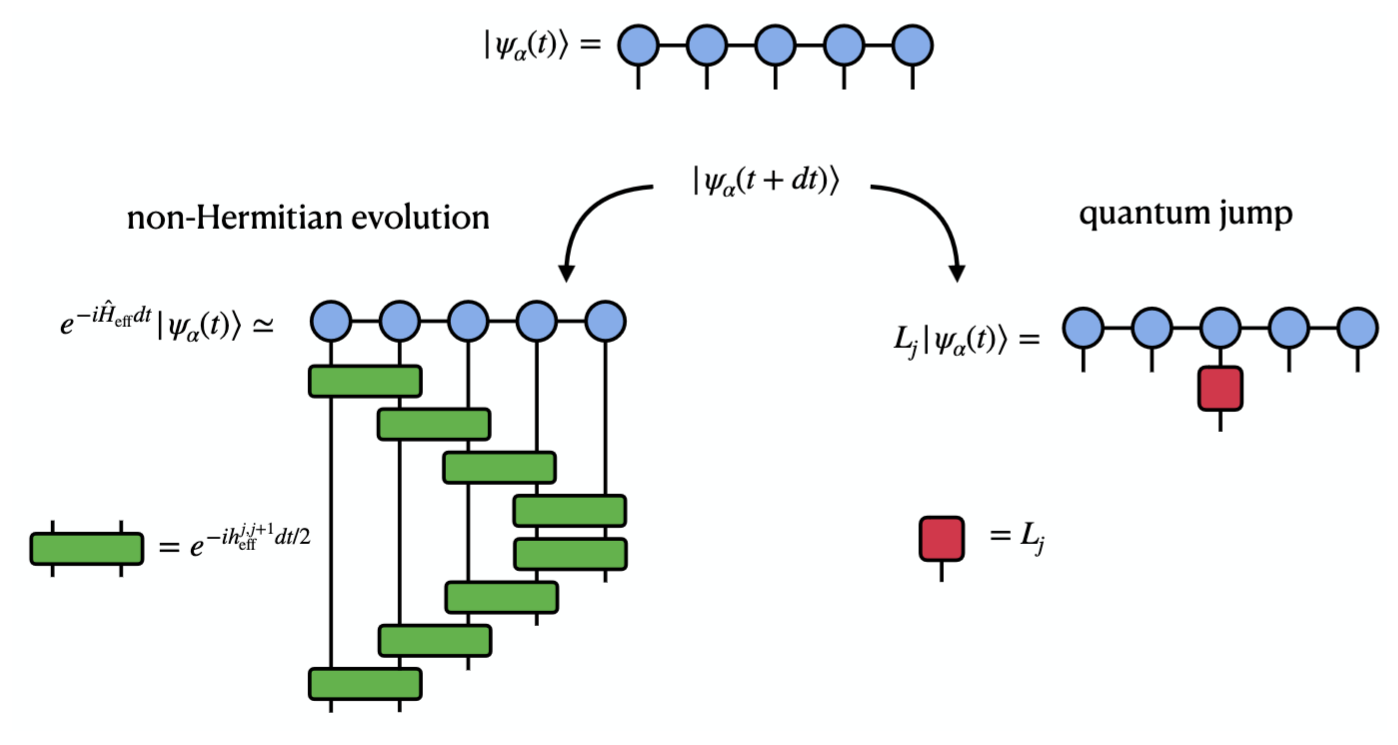

In [2]:
from IPython.display import Image, display
display(Image(filename="MCMPS.png", width=1000))

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg as LA
from ncon import ncon

# ---- local operators -------------------------------------------------------
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

### Core code &mdash; MPS functions

In [4]:
# ==========================================================================
#  MPS  (functions)
# ==========================================================================
def mps_product(configs):
    """Product-state MPS from a list of single-site vectors (each length d)."""
    return [np.array(c, dtype=complex).reshape(1, len(c), 1) for c in configs]


def mps_all_up(N):
    return mps_product([[1, 0]] * N)


def mps_x_plus(N):
    s = 1 / np.sqrt(2)
    return mps_product([[s, s]] * N)


def mps_random(N, d=2, chi=8, seed=None):
    rng = np.random.default_rng(seed)
    dims = [1] + [min(chi, d ** i, d ** (N - i)) for i in range(1, N)] + [1]
    A = []
    for i in range(N):
        t = (rng.standard_normal((dims[i], d, dims[i + 1]))
             + 1j * rng.standard_normal((dims[i], d, dims[i + 1])))
        A.append(t)
    return right_canonicalize(A)[0]


def bond_dims(A):
    return [t.shape[0] for t in A] + [A[-1].shape[2]]


# ---- gauge / canonical form ----------------------------------------------
def qr_left(A_i):
    """A[l,s,r] -> Q[l,s,m] (left-isometry), R[m,r] with A = Q . R."""
    Dl, d, Dr = A_i.shape
    Q, R = LA.qr(A_i.reshape(Dl * d, Dr))
    return Q.reshape(Dl, d, -1), R


def qr_right(A_i):
    """A[l,s,r] -> L[l,m], Q[m,s,r] (right-isometry) with A = L . Q."""
    Dl, d, Dr = A_i.shape
    Q, R = LA.qr(A_i.reshape(Dl, d * Dr).conj().T)
    L = R.conj().T
    Qr = Q.conj().T.reshape(-1, d, Dr)
    return L, Qr


def left_canonicalize(A):
    """Sweep left->right with QR; returns (A_left, tail_norm)."""
    A = [t.copy() for t in A]
    R = np.ones((1, 1), dtype=complex)
    for i in range(len(A)):
        A[i] = ncon([R, A[i]], [[-1, 1], [1, -2, -3]])
        A[i], R = qr_left(A[i])
    return A, R  # R is 1x1 scalar = norm


def right_canonicalize(A):
    """Sweep right->left with QR; returns (A_right, head_norm)."""
    A = [t.copy() for t in A]
    L = np.ones((1, 1), dtype=complex)
    for i in reversed(range(len(A))):
        A[i] = ncon([A[i], L], [[-1, -2, 1], [1, -3]])
        L, A[i] = qr_right(A[i])
    return A, L


def mixed_canonical(A, center):
    """Bring MPS to mixed canonical form with orthogonality centre at `center`.

    Sites < center are left-isometries, sites > center are right-isometries,
    the norm is carried into site `center`.  Returns new list.
    """
    A = [t.copy() for t in A]
    R = np.ones((1, 1), dtype=complex)
    for i in range(center):
        A[i] = ncon([R, A[i]], [[-1, 1], [1, -2, -3]])
        A[i], R = qr_left(A[i])
    A[center] = ncon([R, A[center]], [[-1, 1], [1, -2, -3]])
    L = np.ones((1, 1), dtype=complex)
    for i in reversed(range(center + 1, len(A))):
        A[i] = ncon([A[i], L], [[-1, -2, 1], [1, -3]])
        L, A[i] = qr_right(A[i])
    A[center] = ncon([A[center], L], [[-1, -2, 1], [1, -3]])
    return A


# ---- inner products --------------------------------------------------------
def overlap(bra, ket):
    """<bra|ket> via a left-to-right transfer contraction (ncon)."""
    E = np.ones((1, 1), dtype=complex)
    for B, K in zip(bra, ket):
        E = ncon([E, K, np.conj(B)], [[1, 2], [1, 3, -2], [2, 3, -1]])
    return complex(E[0, 0])


def norm(A):
    return np.sqrt(overlap(A, A).real)


def normalize(A):
    """Return a copy of the MPS rescaled to unit norm."""
    n = norm(A)
    B = [t.copy() for t in A]
    B[0] = B[0] / n
    return B

### Core code &mdash; Observable functions

In [5]:
# ==========================================================================
#  Observables  (functions)
# ==========================================================================
def expectation_1site(A, op, site):
    """<psi|op_site|psi>/<psi|psi> using the mixed-canonical centre."""
    B = mixed_canonical(A, site)
    C = B[site]
    val = ncon([C, op, np.conj(C)], [[1, 2, 3], [4, 2], [1, 4, 3]])
    nrm = ncon([C, np.conj(C)], [[1, 2, 3], [1, 2, 3]])
    return complex(val / nrm).real


def magnetization(A, op=Z):
    return np.array([expectation_1site(A, op, i) for i in range(len(A))])


def correlation(A, opA, opB, i, j):
    """Connected-free two-point <op_i op_j>, i<j, via transfer contraction."""
    if i > j:
        i, j, opA, opB = j, i, opB, opA
    B = mixed_canonical(A, i)
    E = ncon([B[i], opA, np.conj(B[i])], [[1, 2, -2], [3, 2], [1, 3, -1]])
    for k in range(i + 1, j):
        E = ncon([E, B[k], np.conj(B[k])], [[1, 2], [2, 3, -2], [1, 3, -1]])
    E = ncon([E, B[j], opB, np.conj(B[j])],
             [[1, 2], [2, 4, 5], [3, 4], [1, 3, 5]])
    return complex(E).real


def entanglement_entropy(A, bond):
    """Von Neumann entropy across `bond` (between site bond-1 and bond)."""
    center = bond
    B = mixed_canonical(A, center)
    # SVD across the left bond of site `center`
    C = B[center]
    Dl, d, Dr = C.shape
    s = LA.svd(C.reshape(Dl, d * Dr), compute_uv=False)
    p = s ** 2
    p = p / p.sum()
    p = p[p > 1e-16]
    return float(-np.sum(p * np.log(p)))

### Core code &mdash; TEBD functions

In [6]:
# ==========================================================================
#  TEBD  (functions) -- 2nd order Trotter
# ==========================================================================
def ising_bond_gates(N, J, hx, hz, dt, imag=False):
    """Two-site gates exp(-i dt h_bond) for each bond (0..N-2).

    On-site fields are split so every site's field is counted once overall:
    end bonds carry the full field of their outer site.
    """
    tau = (-dt) if imag else (-1j * dt)
    gates = []
    for b in range(N - 1):
        wl = 1.0 if b == 0 else 0.5
        wr = 1.0 if b == N - 2 else 0.5
        h = (-J * np.kron(X, X)
             - hx * (wl * np.kron(X, I2) + wr * np.kron(I2, X))
             - hz * (wl * np.kron(Z, I2) + wr * np.kron(I2, Z)))
        g = _expm_herm(h, tau).reshape(2, 2, 2, 2)
        gates.append(g)
    return gates


def tebd_apply_gate(A, gate, i, chi_max):
    """Apply a two-site gate on bond (i,i+1) to a mixed-canonical MPS at i."""
    theta = ncon([A[i], A[i + 1]], [[-1, -2, 1], [1, -3, -4]])
    theta = ncon([gate, theta], [[-2, -3, 1, 2], [-1, 1, 2, -4]])
    Dl, d1, d2, Dr = theta.shape
    U, S, Vh = LA.svd(theta.reshape(Dl * d1, d2 * Dr), full_matrices=False)
    chi = min(chi_max, int(np.sum(S > 1e-14)))
    chi = max(chi, 1)
    trunc = 1.0 - LA.norm(S[:chi]) / LA.norm(S)
    U, S, Vh = U[:, :chi], S[:chi], Vh[:chi, :]
    S = S / LA.norm(S)
    A[i] = U.reshape(Dl, d1, chi)
    A[i + 1] = (np.diag(S) @ Vh).reshape(chi, d2, Dr)
    return trunc


def tebd_sweep(A, gates, chi_max):
    """One 2nd-order Trotter step: half odd, full even, half odd."""
    N = len(A)
    odd = range(0, N - 1, 2)
    even = range(1, N - 1, 2)
    # A must be left-canonical up to where we start; we re-center each pass
    for i in odd:
        A = mixed_canonical(A, i)
        tebd_apply_gate(A, _half(gates[i]), i, chi_max)
    for i in even:
        A = mixed_canonical(A, i)
        tebd_apply_gate(A, gates[i], i, chi_max)
    for i in odd:
        A = mixed_canonical(A, i)
        tebd_apply_gate(A, _half(gates[i]), i, chi_max)
    return A


def _half(gate):
    """sqrt of a two-site gate via eigendecomposition (for symmetric Trotter)."""
    g = gate.reshape(4, 4)
    w, U = LA.eig(g)
    gh = (U * np.sqrt(w)) @ LA.inv(U)
    return gh.reshape(2, 2, 2, 2)

### Core code &mdash; MCMPS functions

The paper's chain couples along **$z$** ($Z_iZ_{i+1}$), whereas the toolkit's
`ising_bond_gates` couples along $x$; we therefore build the two-site gates here.
`zz_bond_gates` returns the Trotter gates of

$$h^{i,i+1}_{\rm eff}=-\big(J Z_iZ_{i+1}+h_x X_i+h_z Z_i\big)-\tfrac{i}{2}\gamma_d\,n\ \ \text{(distributed over the two sites)},$$

using a **general** (non-Hermitian) matrix exponential via eigendecomposition.
Setting `imag=True` (and $\gamma_d$ ignored) gives the Hermitian imaginary-time
gate $e^{-\tau h}$ used for ground-state preparation.

`apply_gate_nonorm` applies a gate **without** renormalising, so the norm
$\lVert\psi\rVert^2$ decays under $H_{\rm eff}$ &mdash; this decay is exactly what
triggers a quantum jump in the MCWF scheme.


In [7]:
# ---- Monte-Carlo MPS: stochastic unravelling of the Lindblad equation ----
from tqdm import tqdm            # live text progress bar so a running loop is visible

n_op = (Z + I2) / 2.0            # jump operator L_i = n_i = (Z + 1)/2  (measures +z)

def expm_gen(Hmat, tau):
    """exp(tau * Hmat) for a general (possibly non-Hermitian) matrix."""
    w, V = LA.eig(Hmat)
    return (V * np.exp(tau * w)) @ LA.inv(V)

def zz_bond_gates(N, J, hx, hz, gamma, dt, imag=False, half=False):
    """Two-site Trotter gates for the monitored Ising chain (z-z coupling).

    H = -sum_i (J Z_i Z_{i+1} + hx X_i + hz Z_i),
    H_eff = H - i (gamma/2) sum_i n_i.
    imag=True -> imaginary-time gate exp(-tau h) for ground-state prep (gamma ignored).
    half=True -> half Trotter step dt/2 (for the symmetric brickwork sweep).
    On-site fields split so every site is counted once (end bonds carry full field).
    """
    step = (dt / 2.0) if half else dt
    tau = (-step) if imag else (-1j * step)
    gates = []
    for b in range(N - 1):
        wl = 1.0 if b == 0 else 0.5
        wr = 1.0 if b == N - 2 else 0.5
        h = (-J * np.kron(Z, Z)
             - hx * (wl * np.kron(X, I2) + wr * np.kron(I2, X))
             - hz * (wl * np.kron(Z, I2) + wr * np.kron(I2, Z)))
        if not imag:
            h = h - 1j * gamma / 2.0 * (wl * np.kron(n_op, I2) + wr * np.kron(I2, n_op))
        gates.append(expm_gen(h, tau).reshape(2, 2, 2, 2))
    return gates

def apply_gate_nonorm(A, gate, i, chi_max, cutoff=1e-9):
    """Apply a (non-unitary) two-site gate on bond (i,i+1) WITHOUT renormalising."""
    theta = ncon([A[i], A[i + 1]], [[-1, -2, 1], [1, -3, -4]])
    theta = ncon([gate, theta], [[-2, -3, 1, 2], [-1, 1, 2, -4]])
    Dl, d1, d2, Dr = theta.shape
    U, S, Vh = LA.svd(theta.reshape(Dl * d1, d2 * Dr), full_matrices=False)
    chi = max(1, min(chi_max, int(np.sum(S > cutoff))))
    U, S, Vh = U[:, :chi], S[:chi], Vh[:chi, :]
    A[i] = U.reshape(Dl, d1, chi)
    A[i + 1] = (np.diag(S) @ Vh).reshape(chi, d2, Dr)

def _shift_center_right(A, k):
    """Move the orthogonality centre from site k to k+1 with one local QR."""
    Dl, d, Dr = A[k].shape
    Q, R = LA.qr(A[k].reshape(Dl * d, Dr))
    A[k] = Q.reshape(Dl, d, -1)
    A[k + 1] = ncon([R, A[k + 1]], [[-1, 1], [1, -2, -3]])

def sweep_nonherm(A, gfull, ghalf, chi_max):
    """One 2nd-order Trotter step of the non-Hermitian evolution (half/full/half).

    Each sub-sweep canonicalises ONCE to its first bond, then walks the
    orthogonality centre rightward with a single local QR between gates instead
    of a full re-canonicalisation per gate -- O(N) rather than O(N^2) per sweep,
    numerically identical (equivalent up to gauge, norm to machine precision).
    apply_gate_nonorm leaves the centre on the right site of the bond it acts on.
    """
    N = len(A)
    for gates, bonds in ((ghalf, range(0, N - 1, 2)),
                         (gfull, range(1, N - 1, 2)),
                         (ghalf, range(0, N - 1, 2))):
        bonds = list(bonds)
        A = mixed_canonical(A, bonds[0])          # centre at first acted site
        c = bonds[0]
        for i in bonds:
            while c < i:                          # walk centre right to bond-left site
                _shift_center_right(A, c); c += 1
            apply_gate_nonorm(A, gates[i], i, chi_max)   # centre -> i+1
            c = i + 1
    return A

def apply_local(A, op, i):
    """Apply a single-site operator on site i (used for the jump L_i = n_i)."""
    A = mixed_canonical(A, i)
    A[i] = ncon([op, A[i]], [[-2, 1], [-1, 1, -3]])
    return A

def local_profile(A, op=Z, bond=None):
    """All single-site <op_i> AND the Schmidt entropy across `bond` in ONE
    canonical sweep -- O(N) instead of the O(N^2) of calling magnetization()
    (which re-canonicalises for every site).  Returns (profile[N], S_bond).

    We put the orthogonality centre at site 0, then walk it rightward with a
    single QR per step; at each position the centre tensor gives the exact
    local expectation, and at `bond` its left Schmidt spectrum gives S.
    """
    N = len(A)
    bond = N // 2 if bond is None else bond
    B = mixed_canonical(A, 0)                 # centre at site 0 (tail right-canonical)
    mz = np.zeros(N)
    S = 0.0
    for k in range(N):
        C = B[k]                              # orthogonality centre
        val = ncon([C, op, np.conj(C)], [[1, 2, 3], [4, 2], [1, 4, 3]])
        nrm = ncon([C, np.conj(C)], [[1, 2, 3], [1, 2, 3]])
        mz[k] = complex(val / nrm).real
        if k == bond:
            Dl, d, Dr = C.shape
            s = LA.svd(C.reshape(Dl, d * Dr), compute_uv=False)
            p = s ** 2; p = p / p.sum(); p = p[p > 1e-16]
            S = float(-np.sum(p * np.log(p)))
        if k < N - 1:                         # move centre one site to the right
            Dl, d, Dr = C.shape
            Q, R = LA.qr(C.reshape(Dl * d, Dr))
            B[k] = Q.reshape(Dl, d, -1)
            B[k + 1] = ncon([R, B[k + 1]], [[-1, 1], [1, -2, -3]])
    return mz, S


### Core code &mdash; ground-state preparation and the MCWF trajectory

**Ground state (false vacuum).** We relax the fully-polarised state
$\lvert\uparrow\cdots\uparrow\rangle$ under imaginary-time TEBD with the
pre-quench Hamiltonian $H(h_x,+h_z)$ (reusing the toolkit's renormalising
`tebd_sweep` with our $z$-$z$ gates). For $h_x/J=0.8,\,h_z/J=0.08$ this is a
weakly-dressed, almost-polarised state &mdash; the metastable *false vacuum*.

**Trajectory (waiting-time MCWF).** After the quench $h_z\to-h_z$:

1. Draw $r_1\in(0,1)$.
2. Evolve with $H_{\rm eff}$ (non-normalising TEBD) until $\lVert\psi\rVert^2<r_1$.
3. Pick a jump site $i$ with probability $\propto\langle n_i\rangle$, apply $n_i$, renormalise.
4. Repeat.

This is the standard Monte-Carlo wavefunction scheme (see the
[QuTiP Monte-Carlo guide](https://qutip.org/docs/4.5/guide/dynamics/dynamics-monte.html));
the waiting-time formulation is equivalent to drawing a jump each step with
probability $p_i=\gamma_d\,dt\,\langle n_i\rangle$.

Expectation values (`magnetization`, `entanglement_entropy`) internally divide by
$\langle\psi|\psi\rangle$, so they are evaluated correctly on the un-normalised state.


In [8]:
def prepare_false_vacuum(N, J, hx, hz, dtau=0.05, ntau=100, chi=32):
    """Imaginary-time TEBD ground state of H(hx, hz) from the polarised state.

    The longitudinal field -hz*Z favours +z (up) for hz>0 and -z (down) for hz<0;
    we seed the imaginary-time relaxation from the correspondingly polarised product
    state so it converges quickly to the metastable false vacuum.
    """
    A = mps_all_up(N) if hz >= 0 else mps_product([[0, 1]] * N)   # up (+z) or down (-z)
    gates = zz_bond_gates(N, J, hx, hz, 0.0, dtau, imag=True)     # full-step gates
    for _ in range(ntau):
        A = tebd_sweep(A, gates, chi)          # renormalising imaginary-time sweep
    return normalize(A)

def run_trajectory(psi0, N, J, hx, hz, gamma, dt, nt, chi_max, rng):
    """One MCMPS quantum trajectory. Returns (mz_tot[t], S_half[t], jumps).

    mz_tot = sum_i <Z_i>,  S_half = entanglement entropy across the central bond.
    """
    gf = zz_bond_gates(N, J, hx, hz, gamma, dt, half=False)
    gh = zz_bond_gates(N, J, hx, hz, gamma, dt, half=True)
    psi = [a.copy() for a in psi0]
    mz  = np.zeros(nt + 1)
    ent = np.zeros(nt + 1)
    jumps = []
    prof, S = local_profile(psi, Z, N // 2)               # one canonical sweep -> all <Z_i> + S
    mz[0], ent[0] = prof.sum(), S
    norm2, j = 1.0, 1
    while j <= nt:
        r1 = rng.random()
        # ---- non-Hermitian drift until the norm drops below r1 --------------
        while norm2 > r1 and j <= nt:
            psi   = sweep_nonherm(psi, gf, gh, chi_max)
            norm2 = overlap(psi, psi).real
            prof, S = local_profile(psi, Z, N // 2)        # expectation divides by norm
            mz[j], ent[j] = prof.sum(), S
            j += 1
        if j > nt:
            break
        # ---- quantum jump: site i with probability proportional to <n_i> ----
        occ = (prof + 1.0) / 2.0                           # reuse last profile
        i = int(rng.choice(N, p=occ / occ.sum()))
        psi = normalize(apply_local(psi, n_op, i))
        norm2 = 1.0
        jumps.append((j, i))
        prof, S = local_profile(psi, Z, N // 2)
        mz[j], ent[j] = prof.sum(), S
        j += 1
    return mz, ent, jumps

In the analysis of the false vacuum decay one of the main observables routinely utilized in the
literature s the magnetization fidelity
$$F(t)=\frac{\sum_i (\langle \sigma^z_i(t)\rangle_t+\langle\sigma^z_i(0)\rangle_t)}{2\sum_i\langle \sigma^z_i(0)\rangle_t}$$

In [9]:
def mcmps_fidelity(N, J, hx, hz, gamma, dt, nt, chi_max, ntraj, seed=0,
                   dtau=0.05, ntau=100, desc=None):
    """Trajectory-averaged magnetisation fidelity F(t) (Eq. 18) after the quench.

    False vacuum is the ground state of H(hx, -hz) (magnetised along -z); it is then
    quenched to H(hx, +hz), so the +z measurement drives the chain out of it.
    Returns (times, F, psi0).
    A tqdm progress bar (labelled `desc`) shows the trajectory sampling live.
    """
    psi0 = prepare_false_vacuum(N, J, hx, -hz, dtau, ntau, chi_max)   # down false vacuum
    rng  = np.random.default_rng(seed)
    acc  = np.zeros(nt + 1)
    for _ in tqdm(range(ntraj), desc=desc or f"MCMPS gamma={gamma}", leave=True):
        mz, _, _ = run_trajectory(psi0, N, J, hx, hz, gamma, dt, nt, chi_max, rng)  # quench to +hz
        acc += mz
    mz_mean = acc / ntraj
    mz0 = mz_mean[0]
    F = (mz_mean + mz0) / (2.0 * mz0)          # F(0)=1, F(inf)->1/2
    return dt * np.arange(nt + 1), F, psi0

### Core code &mdash; exact Lindblad benchmark (dense, small $N$)

To validate the stochastic unravelling we integrate the Lindblad equation
exactly for the full Liouvillian superoperator (dimension $4^N$, feasible only
for small $N$). Rather than a dense diagonalisation, we propagate $\rho(t)$ with a
single **Arnoldi/Krylov** exponential action (numpy-only, machine precision, and
$\sim100\times$ faster). We convert the MPS false vacuum to a dense vector so both
methods start from the *identical* state.


In [10]:
def mps_to_dense(A):
    """Contract an MPS (open boundaries) into a full 2**N state vector."""
    T = A[0].reshape(A[0].shape[1], A[0].shape[2])          # (d, r)
    for t in A[1:]:
        T = ncon([T, t], [[-1, 1], [1, -2, -3]])            # (D, d2, r2)
        T = T.reshape(T.shape[0] * T.shape[1], T.shape[2])
    return T.reshape(-1)

def _op_at(o, i, N):
    m = np.array([[1.0]], complex)
    for k in range(N):
        m = np.kron(m, o if k == i else I2)
    return m

def _expm_action_krylov(matvec, v, times, m=80):
    """{ e^{t A} v } for many t from a single Arnoldi factorisation (numpy-only).

    Avoids diagonalising the full Liouvillian: one m-step Arnoldi on the D^2
    vector, then a tiny m x m exponential per output time.  ~100x faster than a
    dense eig of the 2^N x 2^N -> 4^N Liouvillian, to machine precision.
    """
    n = len(v)
    m = min(m, n - 1)
    beta = LA.norm(v)
    Vk = np.zeros((n, m + 1), complex)
    Hm = np.zeros((m + 1, m), complex)
    Vk[:, 0] = v / beta
    for j in range(m):
        w = matvec(Vk[:, j])
        for i in range(j + 1):                       # modified Gram-Schmidt
            Hm[i, j] = np.vdot(Vk[:, i], w)
            w = w - Hm[i, j] * Vk[:, i]
        Hm[j + 1, j] = LA.norm(w)
        if Hm[j + 1, j] < 1e-12:
            m = j + 1
            break
        Vk[:, j + 1] = w / Hm[j + 1, j]
    Hs = Hm[:m, :m]
    e1 = np.zeros(m, complex); e1[0] = 1.0
    w2, U = LA.eig(Hs)
    base = LA.inv(U) @ e1
    return [beta * (Vk[:, :m] @ (U @ (np.exp(w2 * t) * base))) for t in times]

def lindblad_fidelity(N, J, hx, hz, gamma, v0, times):
    """Exact Lindblad F(t) for the quench Hamiltonian H(hx, +hz), initial state v0."""
    H = np.zeros((2 ** N,) * 2, complex)
    for i in range(N - 1):
        H -= J * _op_at(Z, i, N) @ _op_at(Z, i + 1, N)
    for i in range(N):
        H -= hx * _op_at(X, i, N) + hz * _op_at(Z, i, N)      # quenched field +hz
    ns = [_op_at(n_op, i, N) for i in range(N)]
    Sz = sum(_op_at(Z, i, N) for i in range(N))
    D = 2 ** N
    I = np.eye(D)
    Lio = -1j * (np.kron(I, H) - np.kron(H.T, I))
    for ni in ns:                                             # n_i is Hermitian, n_i^2=n_i
        nn = ni.conj().T @ ni
        Lio += gamma * (np.kron(ni.conj(), ni)
                        - 0.5 * np.kron(I, nn) - 0.5 * np.kron(nn.T, I))
    rho0 = np.outer(v0, v0.conj()).reshape(-1)
    rhos = _expm_action_krylov(lambda x: Lio @ x, rho0, times)
    mz0 = np.real(v0.conj() @ (Sz @ v0))
    F = []
    for r in rhos:
        mz = np.real(np.trace(r.reshape(D, D) @ Sz))
        F.append((mz + mz0) / (2.0 * mz0))
    return np.array(F)


## Benchmark &mdash; trajectory average vs. exact Lindblad

Small chain $N=6$: the MCMPS fidelity averaged over $N_{\rm traj}$ trajectories
converges to the exact Lindblad curve, the residual scatter being the statistical
error $\sim 1/\sqrt{N_{\rm traj}}$ (Eq. 13).


Benchmark: sampling trajectories: 100%|█████████| 80/80 [00:17<00:00,  4.50it/s]


initial false-vacuum magnetisation  <sum Z>/N = -0.7939
max |F_MCMPS - F_Lindblad| = 0.022  (statistical, Ntraj=80)


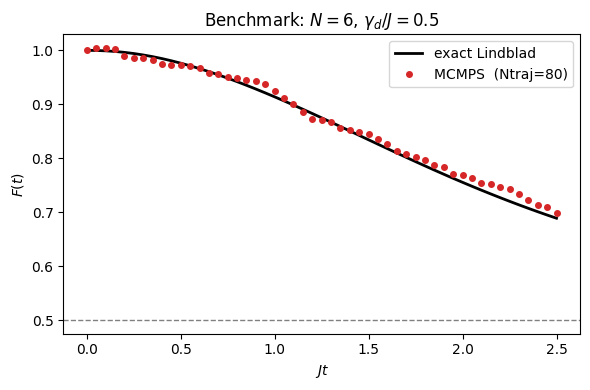

In [11]:
N, J, hx, hz = 6, 1.0, 0.8, 0.08
dt, nt, chi = 0.05, 50, 16
gamma, ntraj = 0.5, 80

t, F_mc, psi0 = mcmps_fidelity(N, J, hx, hz, gamma, dt, nt, chi, ntraj, seed=1,
                               desc="Benchmark: sampling trajectories")
v0 = mps_to_dense(psi0)
F_ex = lindblad_fidelity(N, J, hx, hz, gamma, v0, t)

print(f"initial false-vacuum magnetisation  <sum Z>/N = {magnetization(psi0, Z).mean():.4f}")
print(f"max |F_MCMPS - F_Lindblad| = {np.max(np.abs(F_mc - F_ex)):.3f}"
      f"  (statistical, Ntraj={ntraj})")

plt.figure(figsize=(6, 4))
plt.plot(t, F_ex, 'k-', lw=2, label='exact Lindblad')
plt.plot(t, F_mc, 'o', ms=4, color='tab:red', label=f'MCMPS  (Ntraj={ntraj})')
plt.axhline(0.5, ls='--', color='gray', lw=1)
plt.xlabel(r'$Jt$'); plt.ylabel(r'$F(t)$')
plt.title(fr'Benchmark: $N={N}$, $\gamma_d/J={gamma}$')
plt.legend(); plt.tight_layout(); plt.show()


## Fig. 3 &mdash; measurement-accelerated false-vacuum decay

The magnetisation fidelity (Eq. 18)

$$F(t)=\frac{\sum_i\big(\langle Z_i(t)\rangle+\langle Z_i(0)\rangle\big)}{2\sum_i\langle Z_i(0)\rangle},\qquad F(0)=1,$$

quantifies how far the state has departed from the false vacuum. With no
measurement ($\gamma_d=0$) it is the slow, closed-system false-vacuum decay.
Switching on the monitoring **accelerates** the early decay (the measurement makes
virtual $+z$ spins real, triggering a cascade of jumps), while at long times every
curve thermalises to the infinite-temperature value $F=1/2$ (dashed).

*(Tutorial scale: $N=8$, a handful of $\gamma_d$ values and $N_{\rm traj}$; the
published curves use $N=100$, $N_{\rm traj}\ge600$.)*


Fig.3 gamma/J=0.7: 100%|████████████████████████| 40/40 [00:24<00:00,  1.64it/s]


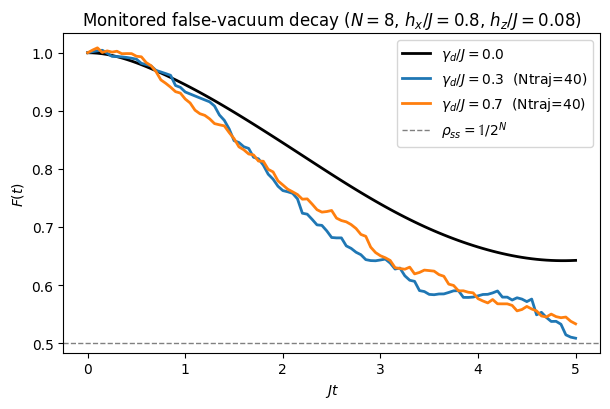

In [12]:
N, J, hx, hz = 8, 1.0, 0.8, 0.08
dt, nt, chi = 0.05, 100, 16
gammas = [0.0, 0.3, 0.7]
ntraj_base = 40

plt.figure(figsize=(6.2, 4.2))
colors = ['k', 'tab:blue', 'tab:orange']
for g, c in zip(gammas, colors):
    ntraj = 1 if g == 0.0 else ntraj_base          # gamma=0 is deterministic
    t, F, _ = mcmps_fidelity(N, J, hx, hz, g, dt, nt, chi, ntraj, seed=7,
                             desc=f"Fig.3 gamma/J={g}")
    plt.plot(t, F, color=c, lw=2, label=fr'$\gamma_d/J={g}$'
             + ('' if g == 0.0 else f'  (Ntraj={ntraj})'))
plt.axhline(0.5, ls='--', color='gray', lw=1, label=r'$\rho_{ss}=\mathbb{1}/2^N$')
plt.xlabel(r'$Jt$'); plt.ylabel(r'$F(t)$')
plt.title(fr'Monitored false-vacuum decay ($N={N}$, $h_x/J={hx}$, $h_z/J={hz}$)')
plt.legend(); plt.tight_layout(); plt.show()


## A single quantum trajectory

Unlike the smooth Lindblad average, one trajectory is a **stochastic** history:
smooth non-Hermitian drift punctuated by abrupt jumps $n_i$ (dotted lines). Each
jump projects a random site onto $+z$ and produces a kink in the magnetisation and
a jump in the half-chain entanglement entropy &mdash; a genuinely trajectory-dependent
quantity (Eq. 12) accessible only in the MPS unravelling.


3 quantum jumps at sites [1, 1, 1]


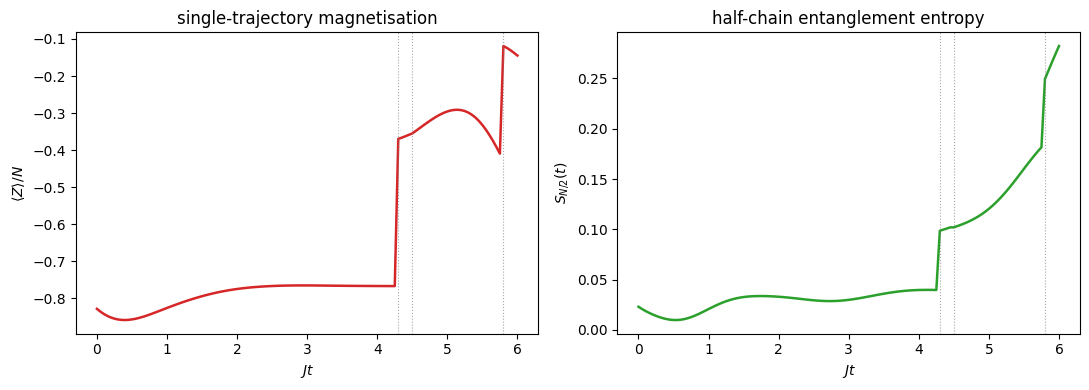

In [13]:
N, J, hx, hz = 8, 1.0, 0.8, 0.08
dt, nt, chi = 0.05, 120, 16
gamma = 0.7

psi0 = prepare_false_vacuum(N, J, hx, -hz)          # false vacuum points -z (down)
rng = np.random.default_rng(3)
mz, ent, jumps = run_trajectory(psi0, N, J, hx, hz, gamma, dt, nt, chi, rng)  # quench to +hz
t = dt * np.arange(nt + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, mz / N, color='tab:red', lw=1.8)
ax[0].set_xlabel(r'$Jt$'); ax[0].set_ylabel(r'$\langle Z\rangle/N$')
ax[0].set_title('single-trajectory magnetisation')
ax[1].plot(t, ent, color='tab:green', lw=1.8)
ax[1].set_xlabel(r'$Jt$'); ax[1].set_ylabel(r'$S_{N/2}(t)$')
ax[1].set_title('half-chain entanglement entropy')
for (jt, ji) in jumps:
    for a in ax:
        a.axvline(t[jt], color='gray', ls=':', lw=0.8, alpha=0.7)
print(f"{len(jumps)} quantum jumps at sites {[ji for _, ji in jumps]}")
plt.tight_layout(); plt.show()


## Fig. 5 &mdash; space-time map of a single trajectory

We now record the **full local magnetisation profile** $\langle Z_i(t)\rangle$ of a
single quantum trajectory and plot it as a space&ndash;time colour map (site $i$
horizontal, $Jt$ vertical) for increasing measurement rate $\gamma_d$.

* $\gamma_d=0$ (closed): the bulk stays pinned in the false vacuum ($\langle Z\rangle<0$,
  dark/purple); only the **boundaries** relax &mdash; a finite-size effect that, thanks to
  the non-Hermitian drift, does not penetrate into the bulk.
* $\gamma_d>0$: each quantum jump projects a single site onto $+z$ (yellow), nucleating an
  up-bubble in the down vacuum; this one-site domain wall then **spreads ballistically**,
  seeding further jumps. The number of jumps grows with both $t$ and $\gamma_d$, melting
  the order faster.

*(Tutorial scale: $N=14$; the paper uses $N=100$.)*


Fig.5 gamma sweep: 100%|██████████████████████████| 6/6 [00:13<00:00,  2.31s/it]


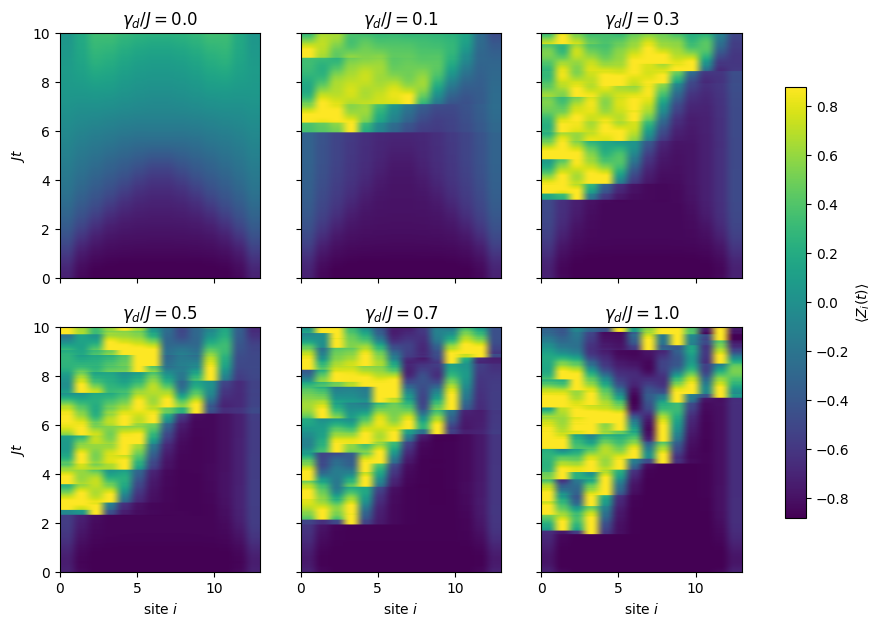

In [14]:
def trajectory_profile(psi0, N, J, hx, hz, gamma, dt, nt, chi_max, rng):
    """Single trajectory; record the full profile <Z_i(t)> at every step."""
    gf = zz_bond_gates(N, J, hx, hz, gamma, dt, half=False)
    gh = zz_bond_gates(N, J, hx, hz, gamma, dt, half=True)
    psi = [a.copy() for a in psi0]
    prof = np.zeros((nt + 1, N))
    prof[0], _ = local_profile(psi, Z)                # single canonical sweep (O(N))
    norm2, j = 1.0, 1
    while j <= nt:
        r1 = rng.random()
        while norm2 > r1 and j <= nt:                 # non-Hermitian TEBD drift
            psi   = sweep_nonherm(psi, gf, gh, chi_max)
            norm2 = overlap(psi, psi).real
            prof[j], _ = local_profile(psi, Z)
            j += 1
        if j > nt:
            break
        occ = (prof[j - 1] + 1.0) / 2.0               # quantum jump on site i ~ <n_i>
        i = int(rng.choice(N, p=occ / occ.sum()))
        psi = normalize(apply_local(psi, n_op, i))
        norm2 = 1.0
        prof[j], _ = local_profile(psi, Z)
        j += 1
    return prof

N, J, hx, hz = 14, 1.0, 0.8, 0.08
dt, nt, chi = 0.05, 200, 12
gammas = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]

psi0 = prepare_false_vacuum(N, J, hx, -hz)          # false vacuum points -z (down)
Jt_max = dt * nt

fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True, sharey=True)
im = None
for ax, g in tqdm(list(zip(axes.flat, gammas)), desc="Fig.5 gamma sweep"):
    rng = np.random.default_rng(2)
    prof = trajectory_profile(psi0, N, J, hx, hz, g, dt, nt, chi, rng)  # quench to +hz
    im = ax.imshow(prof, origin='lower', aspect='auto', cmap='viridis',
                   vmin=-0.88, vmax=0.88, extent=[0, N - 1, 0, Jt_max])
    ax.set_title(fr'$\gamma_d/J={g}$')
for ax in axes[-1]:
    ax.set_xlabel(r'site $i$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$Jt$')
fig.colorbar(im, ax=axes, label=r'$\langle Z_i(t)\rangle$', shrink=0.8)
plt.show()


## Summary

* **MCMPS** = quantum-trajectory (MCWF) unravelling of the Lindblad equation with
  each pure-state trajectory stored as an **MPS** and evolved by **TEBD**.
* The continuous $+z$ measurement enters as a **non-Hermitian drift**
  $H_{\rm eff}=H-\tfrac{i}{2}\gamma_d\sum_i n_i$ (norm-decaying TEBD) plus stochastic
  **jumps** $n_i$ selected with the waiting-time rule $\lVert\psi\rVert^2<r_1$.
* Averaging trajectories reproduces the exact **Lindblad** dynamics
  (benchmark: $\max|F_{\rm MCMPS}-F_{\rm Lindblad}|\sim1/\sqrt{N_{\rm traj}}$).
* **Physics**: measurement **accelerates** the false-vacuum decay at intermediate
  times and drives the chain to the infinite-temperature state $F\to1/2$, exactly
  the scenario of Maki *et al.*, SciPost Phys. 15, 152 (2023).
* Trajectory-resolved quantities (single-shot magnetisation, entanglement entropy)
  are accessible **only** in the unravelling, not from the mean density matrix.
